In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
# 全局样式优化（一次设置，所有图表生效）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 微软雅黑（适配更多系统）
plt.rcParams['axes.unicode_minus'] = False            # 解决负号显示
plt.rcParams['axes.grid'] = True                      # 默认显示网格
plt.rcParams['grid.alpha'] = 0.3                      # 网格透明度
plt.rcParams['figure.facecolor'] = 'white'            # 图表背景色
plt.rcParams['axes.facecolor'] = '#f8f9fa'            # 坐标轴背景色

In [26]:
file_path = r'plot_optimize.csv'

df = pd.read_csv(
    file_path,
    encoding='utf-8',
    parse_dates=['日期'],
    index_col='日期'
)

df

,手机销量,耳机销量,总销售额,城市
日期,,,,
2024-05-01,20,15,65965,北京
2024-05-02,25,18,90950,北京
2024-05-03,18,12,69962,北京
2024-05-04,30,20,116940,北京
2024-05-05,22,16,82956,北京
2024-05-06,19,14,73962,北京
2024-05-07,28,19,107944,北京


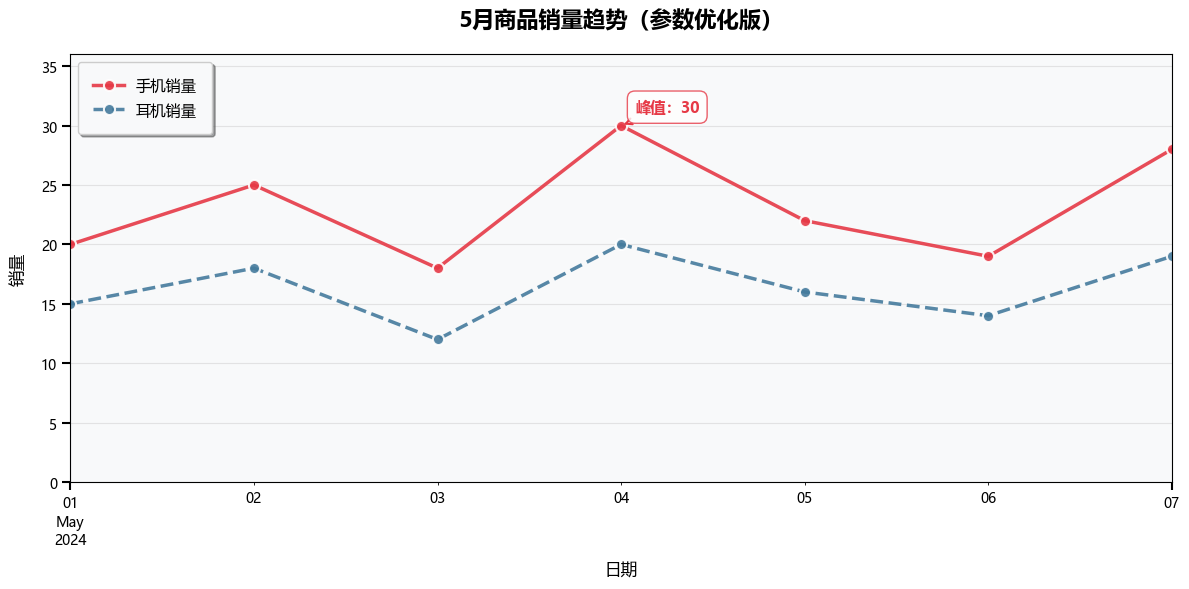

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 第一步：先绘制基础折线图（只传统一线型，后面单独修改）
ax = df[['手机销量', '耳机销量']].plot(
    kind='line',
    figsize=(12, 6),
    color=['#E63946', '#457B9D'],
    linewidth=2.5,
    linestyle='-',        # 先统一用实线
    marker='o',
    markersize=8,
    markeredgecolor='white',
    markeredgewidth=1.5,
    alpha=0.9,
    legend=False
)

# 第二步：单独修改第二条线为虚线 ✅ 核心修复
ax.lines[1].set_linestyle('--')

# 标题与标签
ax.set_title('5月商品销量趋势（参数优化版）', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('日期', fontsize=12, labelpad=10)
ax.set_ylabel('销量', fontsize=12, labelpad=10)

# 图例
ax.legend(
    labels=['手机销量', '耳机销量'],
    loc='upper left', fontsize=11,
    frameon=True, fancybox=True, shadow=True, borderpad=1
)

# 刻度样式
ax.tick_params(axis='both', labelsize=10, length=6, width=1.5)

# Y轴范围
ax.set_ylim(0, max(df['手机销量'].max(), df['耳机销量'].max()) * 1.2)

peak_idx = df['手机销量'].idxmax()  # 销量峰值日期
peak_val = df['手机销量'].max()

ax.annotate(f'峰值：{peak_val}',      # 标注文本
    xy=(peak_idx, peak_val), # 标注位置
    xytext=(10, 10),         # 文本偏移
    textcoords='offset points',
    fontsize=11,
    fontweight='bold',
    color='#E63946',
    bbox=dict(               # 标注框样式
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.8,
        edgecolor='#E63946'),
    arrowprops=dict(         # 箭头样式
        arrowstyle='->',
        color='#E63946',
        lw=1.5)
)

plt.tight_layout()  # 自动调整布局，避免元素重叠

plt.savefig('销量趋势_优化版.png',
    dpi=300,                # 分辨率（300DPI，高清）
    bbox_inches='tight'     # 保存时裁剪空白
)

plt.show()

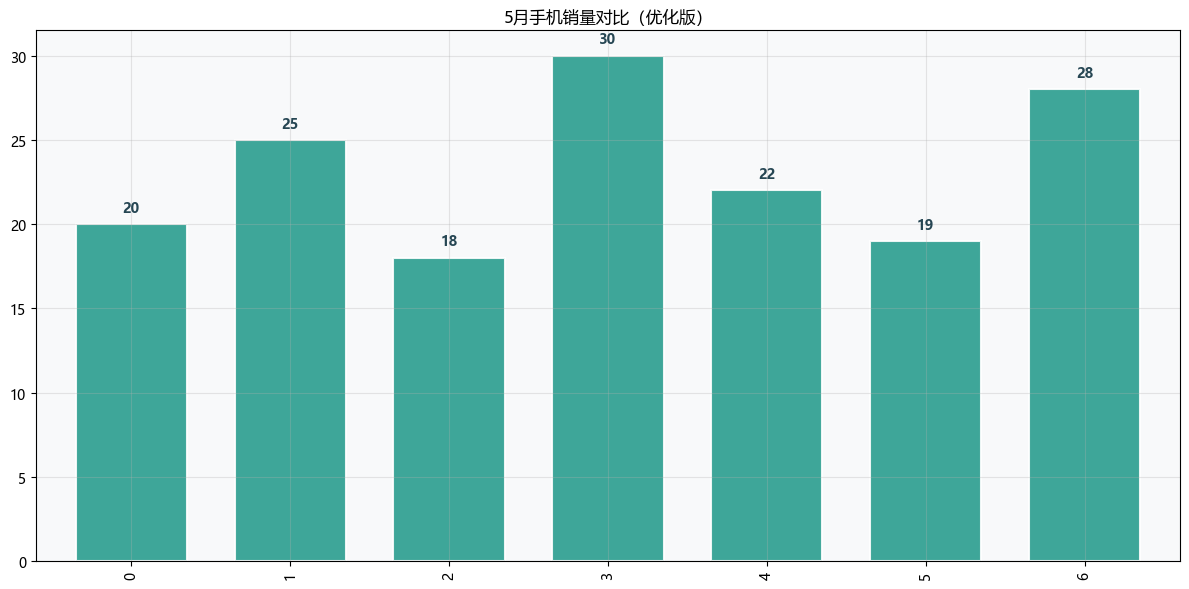

In [28]:
ax2 = df['手机销量'].plot(
    kind='bar',
    figsize=(12, 6),
    title='5月手机销量对比（优化版）',
    color='#2A9D8F',
    width=0.7,               # 柱子宽度
    edgecolor='white',       # 柱子边框
    linewidth=1.5,
    alpha=0.9,
    use_index=False   # 核心修复：强制关闭索引自动解析
)

for i, v in enumerate(df['手机销量']):
    ax2.text(
        i, v+0.5, str(v),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#264653'
    )

plt.tight_layout()
plt.show()

In [29]:
def set_plot_style():
    plt.rcParams.update({'font.sans-serif': ['SimHei', 'Microsoft YaHei', 'DejaVu Sans'],'axes.unicode_minus': False,'figure.dpi': 100,'savefig.dpi': 300})
set_plot_style()  # 调用生效


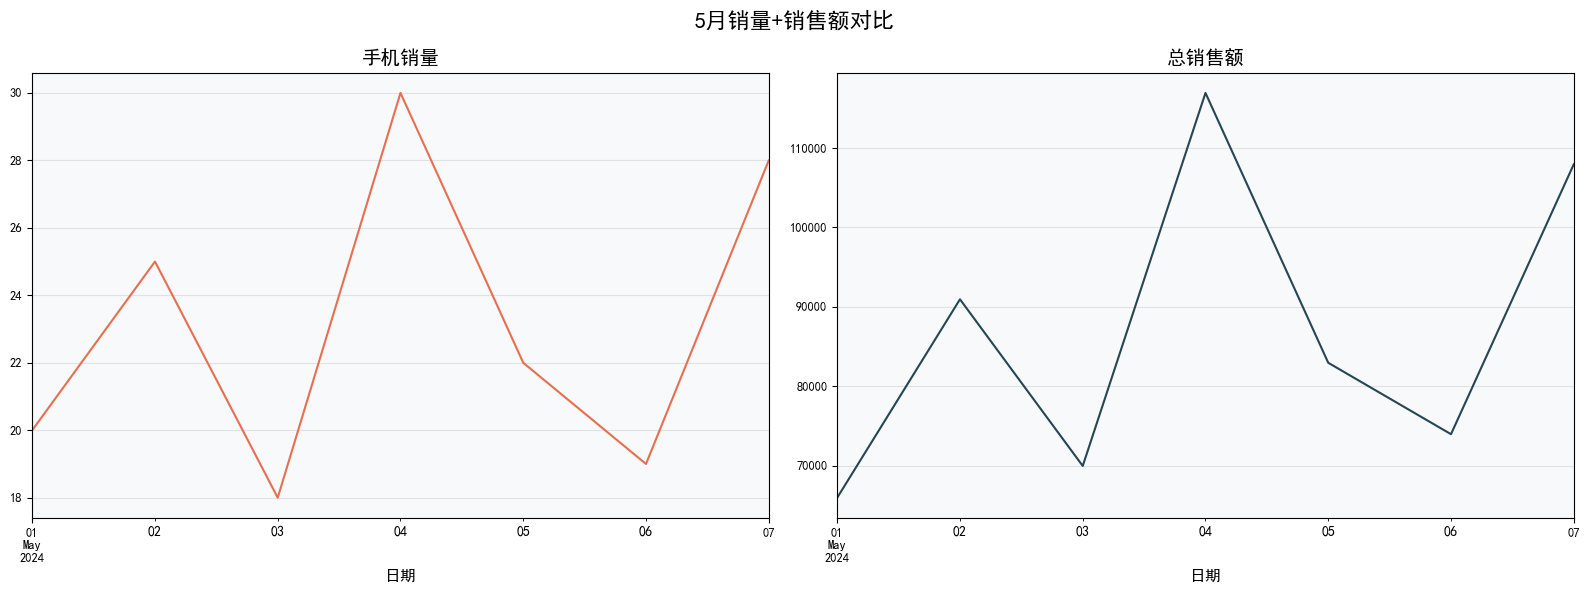

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df['手机销量'].plot(kind='line', ax=ax1, color='#E76F51', title='手机销量')
df['总销售额'].plot(kind='line', ax=ax2, color='#264653', title='总销售额')

for ax in [ax1, ax2]:
    ax.set_xlabel('日期', fontsize=11)
    ax.tick_params(labelsize=9)
    ax.title.set_fontsize(14)
fig.suptitle('5月销量+销售额对比', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()